In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt

PyReduce defines instruments as subclasses of `pyreduce.instruments.Instrument` which live as sub-packages in `pyreduce.instruments`. It contains methods to load and parse raw FITS files and extract re
Most `Instrument` methods can be directly inherited, some may need to be overriden if the instrument package location is not in pyreduce's default instruments folder. A custom instrument class can be instantiated with the path to instrument yaml config as well.

For ZShooter, we have created a custom instrument package `zshooter-drp/src/zsdrp/ZSHOOTER` which defines the `ZSHOOTER` instrument class and contains the configuration yaml. The config yaml specifies header keywords to look for when loading/parsing raw data.

In [2]:
### Method 1: use instant custom instrument creation
from pyreduce.instruments.common import create_custom_instrument
zs = create_custom_instrument(name='ZSHOOTER', extension=1, info='ZSHOOTER/config.yaml')

In [3]:
### Method 2: import zshooter instrument class directly that correctly loads config info
from ZSHOOTER import ZSHOOTER
zs = ZSHOOTER()

PyReduce processes channels separately, so we need to supply the channel name when loading data.

In [4]:
channel = 'B' # or 'G', 'R', 'YJ', 'H', 'K'

### Bias combine step (simple)

In [5]:
from pyreduce.reduce import combine_bias

bias_files = sorted(glob.glob('../../../zs-scopesim/dev_notebooks/sims/bias_B*.fits'))
bias, bhead = combine_bias(bias_files, instrument=zs, channel=channel)

### Flat combine step (simple)

In [6]:
from pyreduce.reduce import combine_calibrate

flat_files = sorted(glob.glob('../../../zs-scopesim/dev_notebooks/sims/flat_B*.fits'))
flat, fhead = combine_calibrate(flat_files, instrument=zs, channel=channel, bias=bias, bhead=bhead)

WARNING - No exposure time set in bias, using number of files instead


### Trace step

Here we need to specify kwarg settings for this step. There are a set of default settings for each step stored in `pyreduce.defaults.settings.json`. For each instrument `settings.json` is created that inherits from the defaults and contains keywords to be overridden specifically for that instrument. For ZShooter, we have created `ZSHOOTER/settings.yaml` which contains settings for all steps.

In [7]:
from utils import config_loader

config = config_loader('ZSHOOTER/settings.yaml')
tcfg = config.get('trace')
tcfg

{'degree': 5,
 'degree_before_merge': 2,
 'bias_scaling': 'exposure_time',
 'norm_scaling': 'none',
 'regularization': 0,
 'closing_shape': [2, 2],
 'opening_shape': [1, 1],
 'auto_merge_threshold': 0.9,
 'merge_min_threshold': 0.5,
 'split_sigma': 0,
 'filter_x': 0,
 'filter_y': 5,
 'filter_type': 'boxcar',
 'min_cluster': 15000,
 'min_width': 0.3,
 'noise': 0,
 'noise_relative': 0.001,
 'border_width': [30, 20, 100, 100],
 'manual': False,
 'plot': True,
 'plot_title': 'Order Tracing'}

INFO - Found 1114 clusters initially
INFO - Removed 1088 clusters smaller than min_cluster=15000, 25 remain


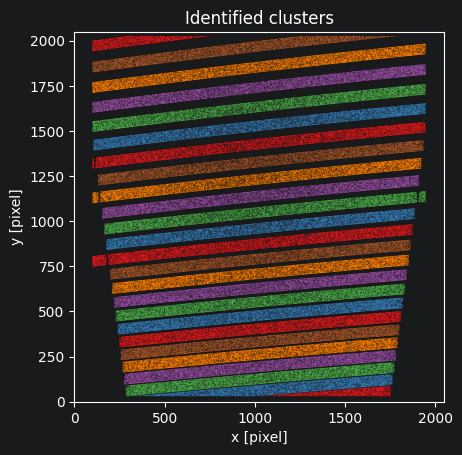

INFO - Fitting polynomials to 25 clusters
INFO - Assigned order/fiber to 25 traces


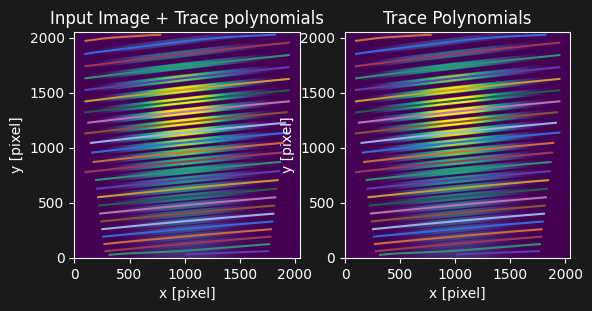

In [8]:
from pyreduce.trace import trace

## we will use flat image for trace identification
traces = trace(flat,
               min_cluster=tcfg['min_cluster'],
               min_width=tcfg['min_width'],
               filter_x=tcfg['filter_x'],
               filter_y=tcfg['filter_y'],
               filter_type=tcfg['filter_type'],
               noise=tcfg['noise'],
               noise_relative=tcfg['noise_relative'],
               degree=tcfg['degree'],
               border_width=tcfg['border_width'],
               degree_before_merge=tcfg['degree_before_merge'],
               regularization=tcfg['regularization'],
               closing_shape=tcfg['closing_shape'],
               opening_shape=tcfg['opening_shape'],
               plot=True,
               plot_title=None,
               manual=tcfg['manual'],
               auto_merge_threshold=tcfg['auto_merge_threshold'],
               merge_min_threshold=tcfg['merge_min_threshold'],
               sigma=tcfg['split_sigma'],
               debug_dir=None,
               order_centers=None)

### Curvature step

In [12]:
config = config_loader('ZSHOOTER/settings.yaml')
ccfg = config.get('curvature')
ccfg

{'dimensionality': '2D',
 'degree': [1, 1],
 'curve_degree': 1,
 'extraction_method': 'simple',
 'collapse_function': 'median',
 'curve_height': 0.9,
 'extraction_height': 1,
 'curvature_cutoff': 3,
 'peak_threshold': 10,
 'peak_width': 1,
 'window_width': 9,
 'peak_function': 'gaussian',
 'bias_scaling': 'exposure_time',
 'norm_scaling': 'divide',
 'plot': True,
 'plot_title': 'Slit Curvature'}

WARNING - No exposure time set in bias, using number of files instead
INFO - Determining the Slit Curvature


Trace: 100%|██████████| 25/25 [19:53<00:00, 47.72s/it]


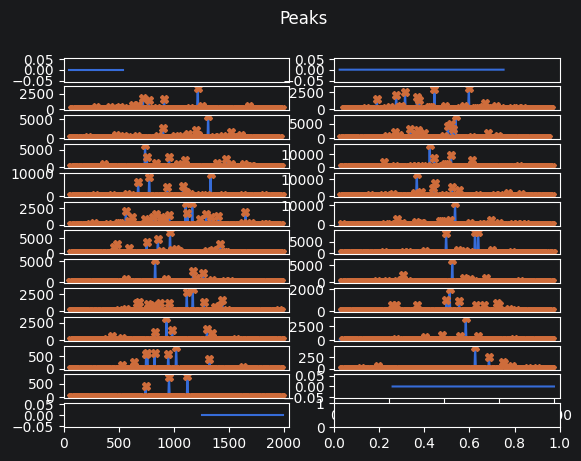

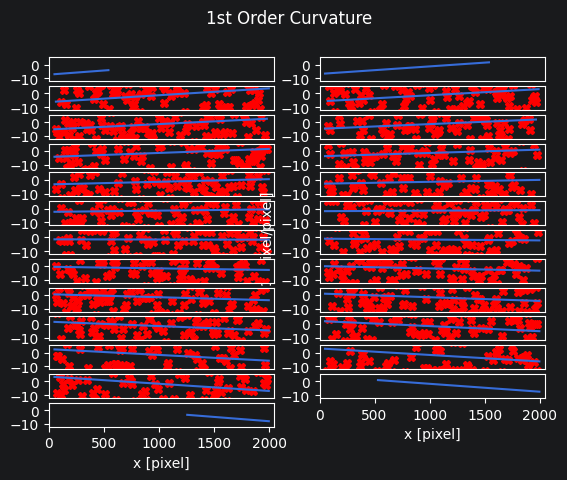

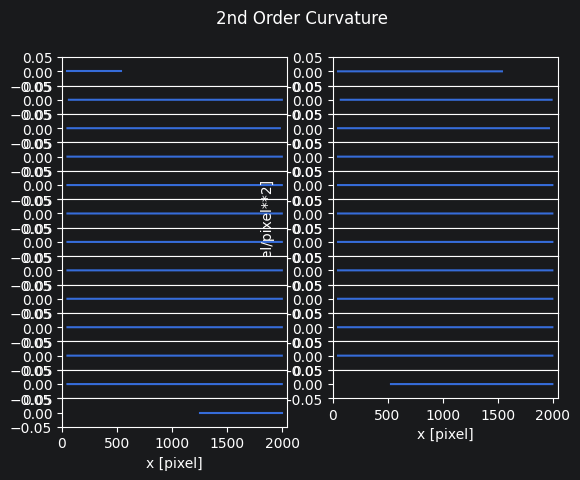

INFO - Computed slitdeltas with shape (25, 77), range [-564.0592, 440.9167]


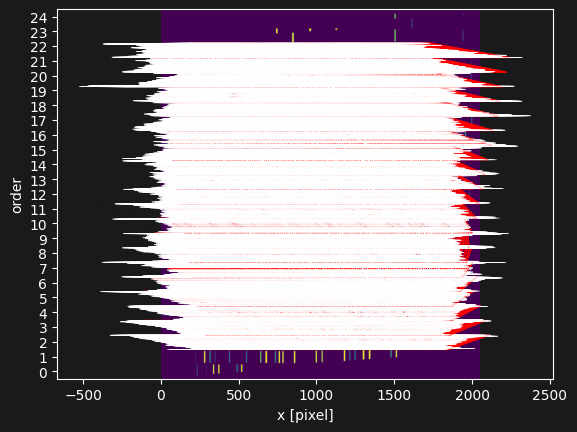

In [16]:
arc_files = sorted(glob.glob('../../../zs-scopesim/dev_notebooks/sims/arcs_B*.fits'))
arc, ahead = combine_calibrate(arc_files, instrument=zs, channel=channel, bias=bias, bhead=bhead)

from pyreduce.slit_curve import Curvature
curvmod = Curvature(traces=traces,
                    curve_height=ccfg['curve_height'],
                    extraction_height=ccfg['extraction_height'],
                    trace_range=None,
                    fit_degree=ccfg['degree'],
                    curve_degree=ccfg['curve_degree'],
                    sigma_cutoff=ccfg['curvature_cutoff'],
                    mode=ccfg['dimensionality'],
                    peak_threshold=ccfg['peak_threshold'],
                    peak_width=ccfg['peak_width'],
                    window_width=ccfg['window_width'],
                    peak_function=ccfg['peak_function'],
                    plot=True,
                    plot_title=None)
curvature = curvmod.execute(arc)
# Update traces in-place with curvature data
fitted_coeffs = curvature["fitted_coeffs"]
slitdeltas = curvature["slitdeltas"]
for i, t in enumerate(traces):
    if fitted_coeffs is not None and i < fitted_coeffs.shape[0]:
        t.slit = fitted_coeffs[i]
    if slitdeltas is not None and i < slitdeltas.shape[0]:
        t.slitdelta = slitdeltas[i]

### Flat normalization step

In [97]:
config = config_loader('ZSHOOTER/settings.yaml')
ncfg = config.get('norm_flat')

extraction_kwargs = {
    "lambda_sf": ncfg["smooth_slitfunction"],
    "lambda_sp": ncfg["smooth_spectrum"],
    "osample": ncfg["oversampling"],
    "swath_width": ncfg["swath_width"],
    "maxiter": ncfg["maxiter"],
    "reject_threshold": ncfg.get("extraction_reject", 6),
}
ncfg

{'extraction_method': 'normalize',
 'smooth_slitfunction': 1000,
 'smooth_spectrum': 0,
 'oversampling': 12,
 'maxiter': 30,
 'swath_width': 200,
 'extraction_height': 0.9,
 'threshold': 1000,
 'threshold_lower': 0,
 'extraction_reject': 6,
 'plot': True,
 'plot_title': 'Normalized Flat'}

INFO - Using optimal extraction to produce spectrum


Swath:   0%|          | 0/17 [00:00<?, ?it/s, chi=0.00]
                                                       
Swath:  33%|███▎      | 1/3 [00:00<00:00,  9.51it/s, chi=0.01]
                                                              
Trace:   8%|▊         | 2/25 [00:00<00:05,  4.37it/s]         

WARNING - Did not finish convergence after maxiter (30) iterations



Swath:  12%|█▏        | 2/17 [00:00<00:02,  5.52it/s, chi=0.07]
                                                               
Swath:  18%|█▊        | 3/17 [00:00<00:03,  4.14it/s, chi=93.80]

WARNING - Did not finish convergence after maxiter (30) iterations


...


                                                                
Swath:  87%|████████▋ | 13/15 [00:02<00:00,  5.44it/s, chi=400.51]

WARNING - Did not finish convergence after maxiter (30) iterations



                                                                  
Trace:  72%|███████▏  | 18/25 [00:56<00:17,  2.54s/it]          

WARNING - Did not finish convergence after maxiter (30) iterations



Trace: 100%|██████████| 25/25 [00:59<00:00,  2.36s/it]


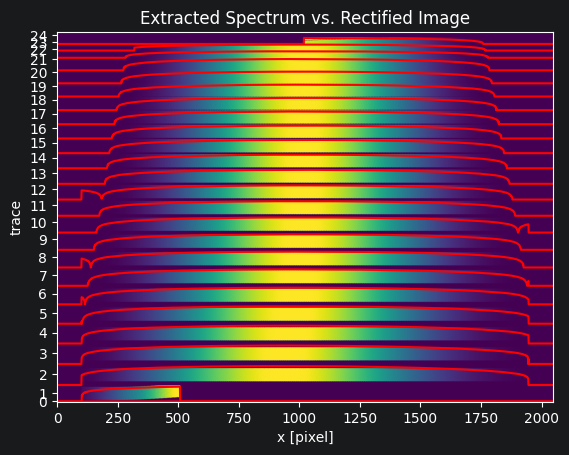

In [98]:
from pyreduce.extract import extract_normalize

norm, _, blaze, slitfunc, column_range = extract_normalize(
    flat,
    traces,
    extraction_height=ncfg['extraction_height'],
    gain=fhead["e_gain"],
    readnoise=fhead["e_readn"],
    dark=fhead["e_drk"],
    scatter=None,
    threshold=ncfg['threshold'],
    threshold_lower=ncfg['threshold_lower'],
    plot=True,
    plot_title=None,
    **extraction_kwargs,
)

blaze = np.ma.filled(blaze, 0)
norm = np.ma.filled(norm, 1)
norm = np.nan_to_num(norm, nan=1)

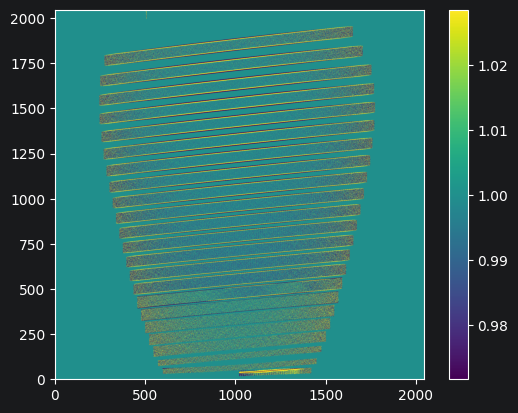

In [99]:
from astropy.visualization import ZScaleInterval
z = ZScaleInterval()
vmin, vmax = z.get_limits(norm)
plt.imshow(norm, vmin=vmin, vmax=vmax, origin='lower')
plt.colorbar()
plt.show()